The scope of this notebook is to implement a residual-stream lens analysis on the hybrid models seen in the previous notebooks.


In [72]:
import os
from pathlib import Path
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
from typing import Dict, List, Optional
from sklearn.decomposition import PCA
import random
import matplotlib.pyplot as plt
import numpy as np
import contextlib
from models import *
from utils import *  

# Load and Prepare Data
First there is the usual setup of loading data and preparing the models.

In [2]:
h3_edges_paris = gpd.read_file('data/h3_edges.geojson')
h3_nodes_paris = gpd.read_file('data/h3_nodes.geojson')
h3_nodes_paris.index = h3_nodes_paris['h3_09']
h3_nodes_paris.drop(columns=['h3_09'], inplace=True)
h3_nodes_paris['Green View Mean'] = h3_nodes_paris['Green View']
h3_nodes_paris['Sky View Mean'] = h3_nodes_paris['Sky View']

h3_edges_amst = gpd.read_file('data/h3_edges_amst.geojson')
h3_nodes_amst = gpd.read_file('data/h3_nodes_amst.geojson')
h3_nodes_amst.index = h3_nodes_amst['h3_09']
h3_nodes_amst.drop(columns=['h3_09'], inplace=True)

h3_edges_milan = gpd.read_file('data/h3_edges_milan.geojson')
h3_nodes_milan = gpd.read_file('data/h3_nodes_milan.geojson')
h3_nodes_milan.index = h3_nodes_milan['h3_09']
h3_nodes_milan.drop(columns=['h3_09'], inplace=True)

h3_edges_barcelona = gpd.read_file('data/h3_edges_barcelona.geojson')
h3_nodes_barcelona = gpd.read_file('data/h3_nodes_barcelona.geojson')
h3_nodes_barcelona.index = h3_nodes_barcelona['h3_09']
h3_nodes_barcelona.drop(columns=['h3_09'], inplace=True)

h3_edges_berlin = gpd.read_file('data/h3_edges_berlin.geojson')
h3_nodes_berlin = gpd.read_file('data/h3_nodes_berlin.geojson')
h3_nodes_berlin.index = h3_nodes_berlin['h3_08']
h3_nodes_berlin.drop(columns=['h3_08'], inplace=True)

h3_edges_edinburgh = gpd.read_file('data/h3_edges_edinburgh.geojson')
h3_nodes_edinburgh = gpd.read_file('data/h3_nodes_edinburgh.geojson')
h3_nodes_edinburgh.index = h3_nodes_edinburgh['h3_09']
h3_nodes_edinburgh.drop(columns=['h3_09'], inplace=True)


device = 'cpu'
input_features = ['x','y','PopSum', 'POI', 'Sky View Mean']
training_city_list = ['paris', 'amsterdam', 'milan', 'barcelona', 'edinburgh']
test_city_list = ['berlin']
h3_edges = {
    'paris': h3_edges_paris,
    'amsterdam': h3_edges_amst,
    'milan': h3_edges_milan,
    'barcelona': h3_edges_barcelona,
    'berlin': h3_edges_berlin,
    'edinburgh': h3_edges_edinburgh
}
h3_nodes= {
    'paris': h3_nodes_paris,
    'amsterdam': h3_nodes_amst,
    'milan': h3_nodes_milan,
    'barcelona': h3_nodes_barcelona,
    'berlin': h3_nodes_berlin,
    'edinburgh': h3_nodes_edinburgh
}
processed_data = {}
for city in training_city_list:
    data = preprocess_data(h3_nodes[city], h3_edges[city], X_list= input_features, target='Green View Mean')
    processed_data[city] = data.to(device)
print(f"Processed data for cities: {list(processed_data.keys())}")

data_list = list(processed_data.values())
train_loader = DataLoader(data_list, batch_size=1, shuffle=True)
for batch in train_loader:
    print(f"Batch size: {batch.num_graphs}, Number of nodes: {batch.num_nodes}, Number of edges: {batch.num_edges}")

test_data = {}
for city in test_city_list:
    data = preprocess_data(h3_nodes[city], h3_edges[city], X_list= input_features, target='Green View Mean')
    test_data[city] = data.to(device)
print(f"Processed test data for cities: {list(test_data.keys())}")
test_loader = DataLoader(list(test_data.values()), batch_size=1, shuffle=False)
for batch in test_loader:
    print(f"Test batch size: {batch.num_graphs}, Number of nodes: {batch.num_nodes}, Number of edges: {batch.num_edges}")

Skipping field osmid: unsupported OGR type: 13
Skipping field osmid: unsupported OGR type: 13
Skipping field osmid: unsupported OGR type: 13
Skipping field osmid: unsupported OGR type: 13
Skipping field osmid: unsupported OGR type: 13
Skipping field osmid: unsupported OGR type: 13


Processed data for cities: ['paris', 'amsterdam', 'milan', 'barcelona', 'edinburgh']
Batch size: 1, Number of nodes: 1228, Number of edges: 6844
Batch size: 1, Number of nodes: 1614, Number of edges: 8300
Batch size: 1, Number of nodes: 1860, Number of edges: 9110
Batch size: 1, Number of nodes: 1605, Number of edges: 8670
Batch size: 1, Number of nodes: 987, Number of edges: 5396
Processed test data for cities: ['berlin']
Test batch size: 1, Number of nodes: 1398, Number of edges: 7698


# Prepare Models

In [3]:
input_features = [['x','y','PopSum', 'POI', 'Sky View Mean']]
models = ['Hybrid']
# build models
models_dict = {}
for model_name in models:
    models_dict[model_name] = {}
    for input_feature in input_features:
        models_dict[model_name][tuple(input_feature)] = model_builder(
            model_name=model_name,
            in_channels= len(input_feature),
            pe_input_dim= processed_data['paris'].pe.shape[1],
            pe_dim=16,
            hidden_channels=64,
            heads=4,
            num_layers=8,
            dropout=0.4
        )
        models_dict[model_name][tuple(input_feature)].to(device)

# Test model output shape
for model_name in models:
    for input_feature in input_features:
        current_model = models_dict[model_name][tuple(input_feature)]
        current_data = {}
        for city in training_city_list:
            data = preprocess_data(h3_nodes[city], h3_edges[city], X_list= input_feature, target='Green View Mean')
            current_data[city] = data.to(device)
        assert current_model(current_data['paris'].x, current_data['paris'].pe, current_data['paris'].edge_index).squeeze().shape == current_data['paris'].y.shape, f"Model {model_name} output shape does not match target shape"
        print(f"Model {model_name} output shape matches target shape")
print(f"Prepared models for training: {list(models_dict.keys())} wihth input features {input_features}")

Model Hybrid output shape matches target shape
Prepared models for training: ['Hybrid'] wihth input features [['x', 'y', 'PopSum', 'POI', 'Sky View Mean']]


Loading model from bestmodels/Hybrid_x_y_PopSum_POI_SkyViewMean.pth
Final Test Results - Loss: 0.0048


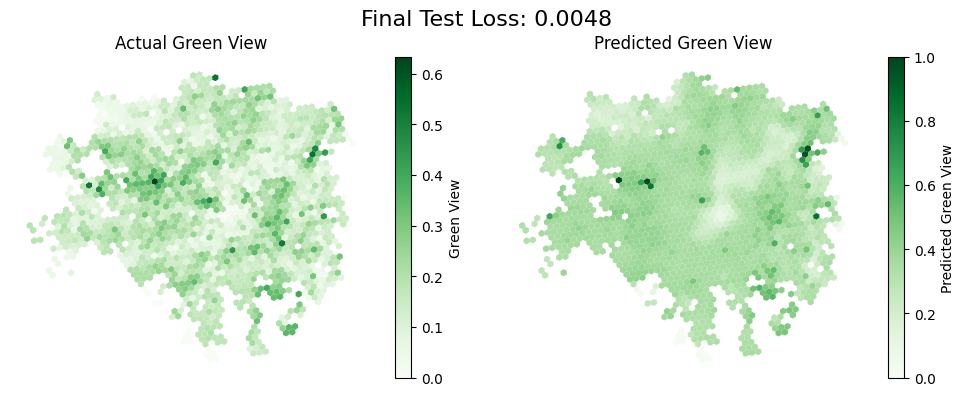

In [141]:
# load model
criterion = torch.nn.MSELoss()
city = 'milan'
feature_string = '_'.join(input_feature).replace(' ', '')
current_model_path = f'bestmodels/{model_name}_{feature_string}.pth'
figure = evaluate_and_visualize_predictions(current_model, processed_data[city], current_model_path, h3_nodes[city], criterion, branch=None, load=True)
figure

Now I will extract all the embeddings from the model and save them in a dictionary

In [142]:
predictions, dbg = current_model(processed_data[city].x, processed_data[city].pe, processed_data[city].edge_index, branch = 'both', debug = True)
dbg['h0'].shape

torch.Size([1605, 64])

In [143]:
for name, stuff in list(dbg['updates']['transformer'].items())[:3]:
    print(name, stuff['update'].shape)

# Make sure:  h_in + update ≈ next layer's h_in
print(torch.allclose(
        dbg['updates']['transformer']['transformer_attn_0']['h_in'] + dbg['updates']['transformer']['transformer_attn_0']['update'],
        dbg['updates']['transformer']['transformer_ffn_0']['h_in'],
        atol=1e-6))

transformer_attn_0 torch.Size([1605, 64])
transformer_ffn_0 torch.Size([1605, 64])
transformer_attn_1 torch.Size([1605, 64])
True


So everything looks good

# Visual path

Highest target index: 397, Lowest target index: 11
Green View for the query node: 0.0


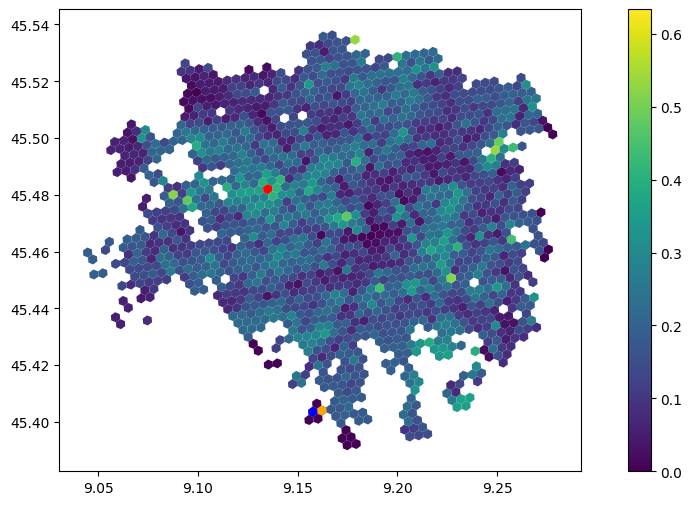

In [152]:
y_true = processed_data[city].y.squeeze()
idx_hi  = torch.argmax(y_true).numpy()     # highest target
idx_lo  = torch.argmin(y_true).numpy()      # lowest  target
idx_qry = 12
print(f"Highest target index: {idx_hi}, Lowest target index: {idx_lo}")
# Visualize the highest and lowest target nodes
h3_nodes_city = h3_nodes[city].copy()
h3_nodes_city.reset_index(inplace=True, drop=True)
h3_nodes_city['highest'] = False
h3_nodes_city['lowest'] = False
f, ax = plt.subplots(1, 1, figsize=(12, 6))
h3_nodes[city].plot(ax=ax, column='Green View Mean', legend=True, cmap='viridis')
h3_nodes_city[h3_nodes_city.index == idx_hi].plot(ax=ax, color='red', markersize=100, label='Highest Green View Mean')
h3_nodes_city[h3_nodes_city.index == idx_lo].plot(ax=ax, color='blue', markersize=100, label='Lowest Green View Mean')
h3_nodes_city[h3_nodes_city.index == idx_qry].plot(ax=ax, color='orange', markersize=100, label='Random Query Node')

print(f"Green View for the query node: {h3_nodes_city.loc[idx_qry, 'Green View Mean']}")

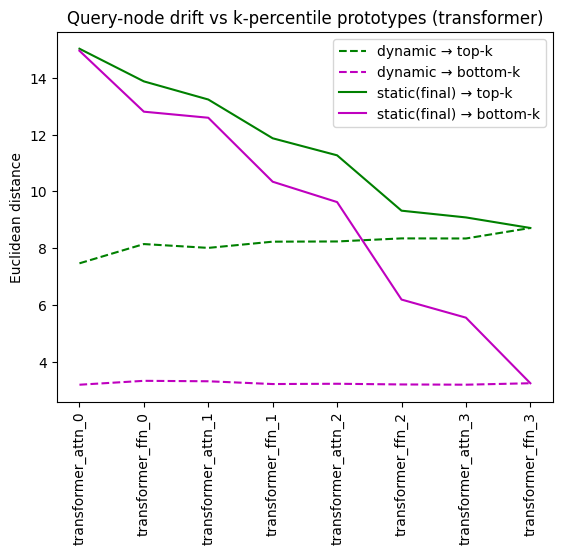

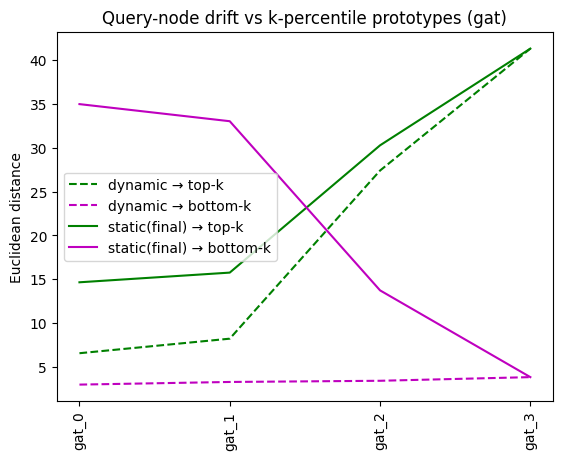

In [153]:
plot_query_node_drift(y_true, dbg, idx_qry, branch='transformer', k=0.01)
plot_query_node_drift(y_true, dbg, idx_qry, branch='gat', k=0.01)

This is a measure of how the query node representation moves in the residual stream relative to two class prototypes built from the data-set targets (top-k % and bottom-k %).


| Curve                        | Line style     | What is compared                                                                                      | Question it answers                                                         |
| ---------------------------- | -------------- | ----------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **dynamic → top-k**          | green dashed   | distance from the query *at layer ℓ* to the centroid of the current top-k nodes *at the same layer ℓ* | *Am I staying close to the “high-target crowd” as everyone moves?*          |
| **dynamic → bottom-k**       | magenta dashed | … to the centroid of the current bottom-k nodes                                                       | *Am I staying away from the low-target crowd right now?*                    |
| **static(final) → top-k**    | green solid    | distance from the query *at layer ℓ* to the **final-layer** centroid of the top-k nodes (fixed point) | *Am I getting nearer to where the high-target prototype will finally live?* |
| **static(final) → bottom-k** | magenta solid  | … to the final-layer bottom-k centroid                                                                | *Am I moving away from the learned low-target region?*                     |


## 2-D Visual Path

In [154]:
query_indices = random.sample(range(processed_data[city].num_nodes), 50)  # Randomly select 10 query nodes
k = 0.01
branch = 'gat'
updates = (dbg['updates'][branch])
y_true = processed_data[city].y.squeeze()
qt_hi = torch.quantile(y_true, 1 - k)
qt_lo = torch.quantile(y_true, k)
mask_hi = (y_true >= qt_hi)
mask_lo = (y_true <= qt_lo)

# Compute final centroids
final_cent_hi = dbg['h0'][mask_hi].clone()
final_cent_lo = dbg['h0'][mask_lo].clone()
for key in updates:
    delta = dbg['updates'][branch][key]['update']
    final_cent_hi += delta[mask_hi]
    final_cent_lo += delta[mask_lo]
final_cent_hi = final_cent_hi.mean(0)
final_cent_lo = final_cent_lo.mean(0)

# Compute trajectories for each query node
trajectories = []
for idx in query_indices:
    h_q = dbg['h0'][idx].clone()
    path = [h_q.clone()]
    for key in updates:
        delta = dbg['updates'][branch][key]['update']
        h_q += delta[idx]
        path.append(h_q.clone())
    trajectories.append(torch.stack(path))

# Stack all for PCA
all_points = torch.cat([traj for traj in trajectories] + [final_cent_hi.unsqueeze(0), final_cent_lo.unsqueeze(0)], dim=0).cpu().numpy()
pca = PCA(n_components=3).fit(all_points)
pca.explained_variance_ratio_

array([0.46324104, 0.2502913 , 0.07203925], dtype=float32)

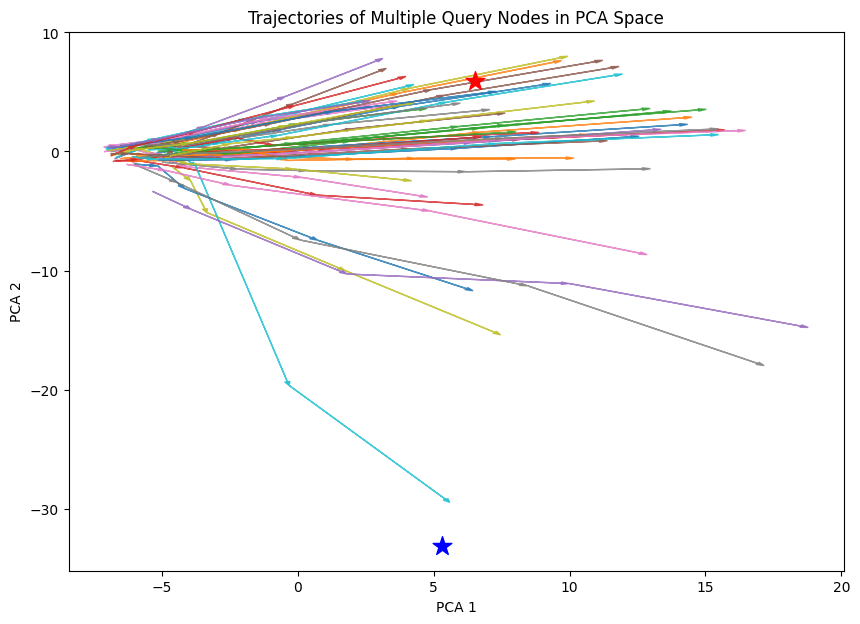

In [155]:
# Plot
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10.colors
for i, traj in enumerate(trajectories):
    xy = pca.transform(traj.cpu())
    # Add arrows for direction
    for j in range(len(xy)-1):
        plt.arrow(xy[j, 0], xy[j, 1], xy[j+1, 0]-xy[j, 0], xy[j+1, 1]-xy[j, 1],
                  color=colors[i % len(colors)], alpha=0.8, head_width=0.2, length_includes_head=True)
    
# Plot centroids
cent_hi_xy = pca.transform(final_cent_hi.unsqueeze(0).cpu())
cent_lo_xy = pca.transform(final_cent_lo.unsqueeze(0).cpu())
plt.scatter(cent_hi_xy[0, 0], cent_hi_xy[0, 1], color='red', marker='*', s=200, label='Top-k Final Centroid')
plt.scatter(cent_lo_xy[0, 0], cent_lo_xy[0, 1], color='blue', marker='*', s=200, label='Bottom-k Final Centroid')
plt.title('Trajectories of Multiple Query Nodes in PCA Space')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
#plt.legend()
plt.show()

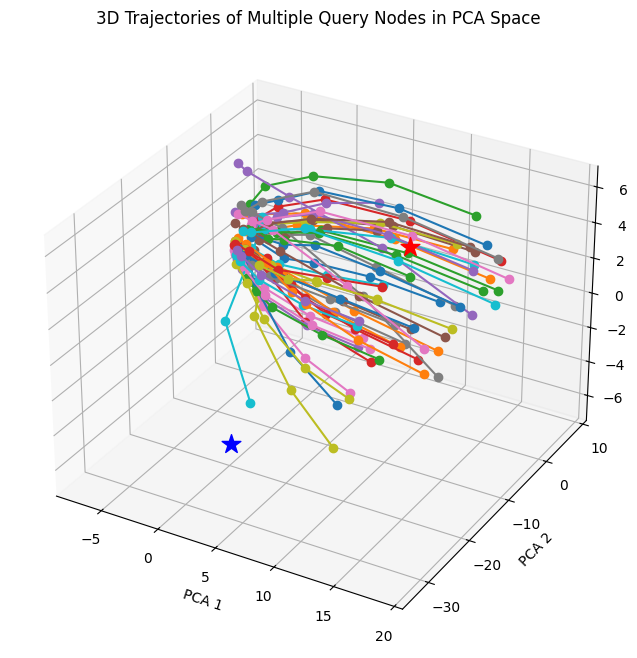

In [156]:
# 3D Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for i, traj in enumerate(trajectories):
    xy = pca.transform(traj.cpu())
    ax.plot(xy[:, 0], xy[:, 1], xy[:, 2], marker='o', label=f'Query {query_indices[i]}', color=colors[i % len(colors)])
# Plot centroids
cent_hi_xy = pca.transform(final_cent_hi.unsqueeze(0).cpu())
cent_lo_xy = pca.transform(final_cent_lo.unsqueeze(0).cpu())
ax.scatter(cent_hi_xy[0, 0], cent_hi_xy[0, 1], cent_hi_xy[0, 2], color='red', marker='*', s=200, label='Top-k Final Centroid')
ax.scatter(cent_lo_xy[0, 0], cent_lo_xy[0, 1], cent_lo_xy[0, 2], color='blue', marker='*', s=200, label='Bottom-k Final Centroid')
ax.set_title('3D Trajectories of Multiple Query Nodes in PCA Space')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
#ax.legend()
plt.show()

[0.3110069 0.2340056 0.1100278]


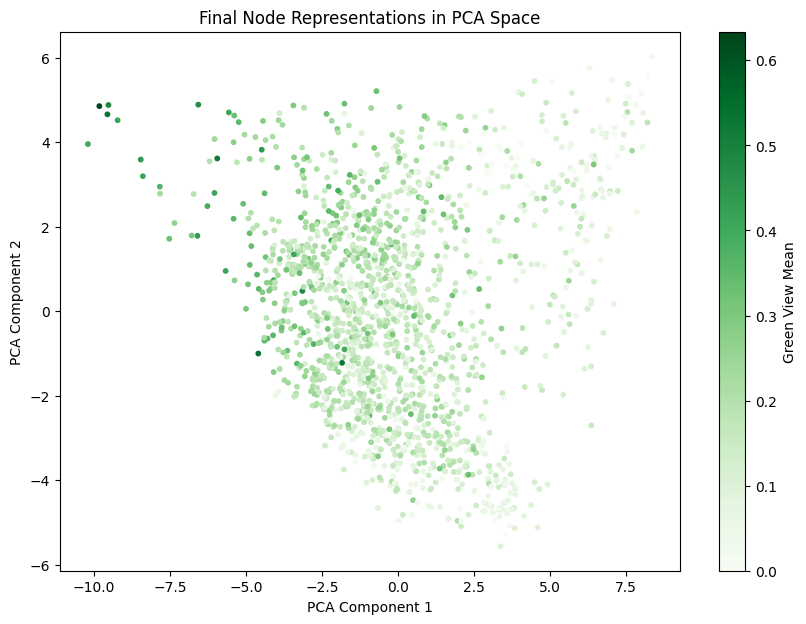

In [157]:
h_final = dbg['h_final']  # shape (N, d)

# Compute PCA for final node representations
pca_final = PCA(n_components=3)
h_final_pca = pca_final.fit_transform(h_final.cpu().numpy())
print(pca_final.explained_variance_ratio_)
# Plot the final node representations in PCA space
plt.figure(figsize=(10, 7))
plt.scatter(h_final_pca[:, 0], h_final_pca[:, 1], cmap= 'Greens', c=y_true.cpu().numpy(), s=10, alpha= 1)
plt.colorbar(label='Green View Mean')
plt.title('Final Node Representations in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

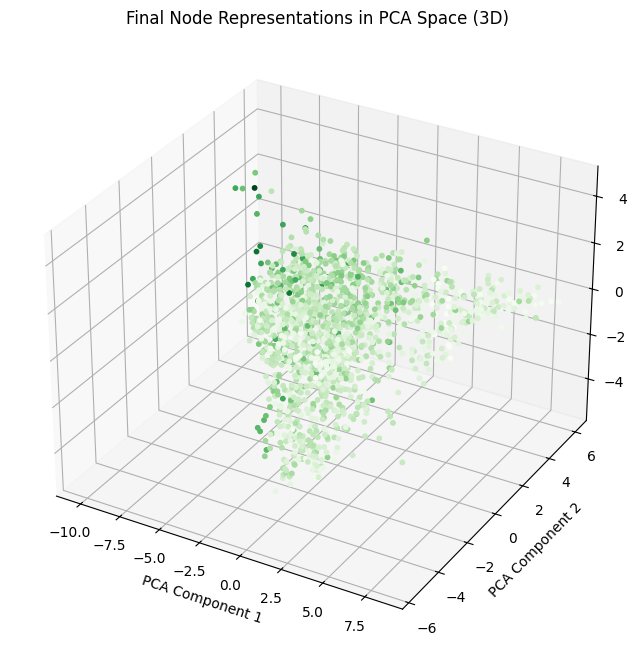

In [150]:
#3d plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(h_final_pca[:, 0], h_final_pca[:, 1], h_final_pca[:, 2], cmap= 'Greens', c=y_true.cpu().numpy(), s=10, alpha= 1)
ax.set_title('Final Node Representations in PCA Space (3D)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.show()